# PEDIC FEEMS dataset demo

This notebook demonstrates:
- Loading the PEDIC FEEMS-style files
- Building pseudo-sites and sampling a GeoTIFF
- Training the multi-species resistance model
- Visualizing learned edge resistances


In [72]:
%load_ext autoreload
%autoreload 2

import os
import sys

import contextily as cx
import numpy as np
import torch

from multispecies_resistance.climate import download_climate_layers
from multispecies_resistance.io import list_species, load_species
from multispecies_resistance.train import build_species_graphs, train_model
from multispecies_resistance.viz import plot_multi_edge_resistance, plot_shared_resistance, plot_sites

torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
PEDIC_DIR = '/Users/isaac/src/meems/pedic_feems_files'
species_names = list_species(PEDIC_DIR)
print(species_names)


['anas_feems', 'brevi_feems', 'crano_feems', 'densis_feems', 'integ_feems', 'kansu_feems', 'lachno_feems', 'longi_feems', 'rhinanth_feems', 'szet_feems', 'tenu_feems', 'vert_feems']


In [74]:
# Download and cache BioClim layers (used below by build_species_graphs)
raster_paths = download_climate_layers(
    source='bioclim',
    variables=['bio1', 'bio12'],
    resolution='2.5m',
    cache_dir='~/.cache/multispecies_resistance/climate',
)
len(raster_paths), raster_paths[:2]


(19,
 [PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_1.tif'),
  PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_2.tif')])

In [75]:
# Load a subset of species (sample-level only)
species_list = load_species(
    PEDIC_DIR,
    coords_order="lonlat",
    species_names=species_names,
    mmap_mode='r',
)
print([s.name for s in species_list])


['anas_feems', 'brevi_feems', 'crano_feems', 'densis_feems', 'integ_feems', 'kansu_feems', 'lachno_feems', 'longi_feems', 'rhinanth_feems', 'szet_feems', 'tenu_feems', 'vert_feems']


In [76]:
# Build graphs and train
graphs, stats = build_species_graphs(
    species_list,
    input_graph="../../pedic_grid/hengduan_grid.gml",
    project_to='EPSG:3857',
    coords_crs='EPSG:4326',
    raster_paths=raster_paths,
    raster_fill_method='nearest',
    standardize=True,
    support_decay_km=150,

)

/Users/isaac/miniconda3/envs/vae-meems/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [77]:
model = train_model(graphs, hidden_dim=32, lr=1e-2, epochs=500, log_every=25, edge_smoothing=0.6)

epoch   25 loss 0.293952 val 0.022975
epoch   50 loss 0.201796 val 0.015396
epoch   75 loss 0.164159 val 0.012608
epoch  100 loss 0.148136 val 0.011540
epoch  125 loss 0.141276 val 0.011088
epoch  150 loss 0.138054 val 0.010888
epoch  175 loss 0.136651 val 0.010776
epoch  200 loss 0.134842 val 0.010669
early stop at epoch 214 val 0.010635 best 0.010730


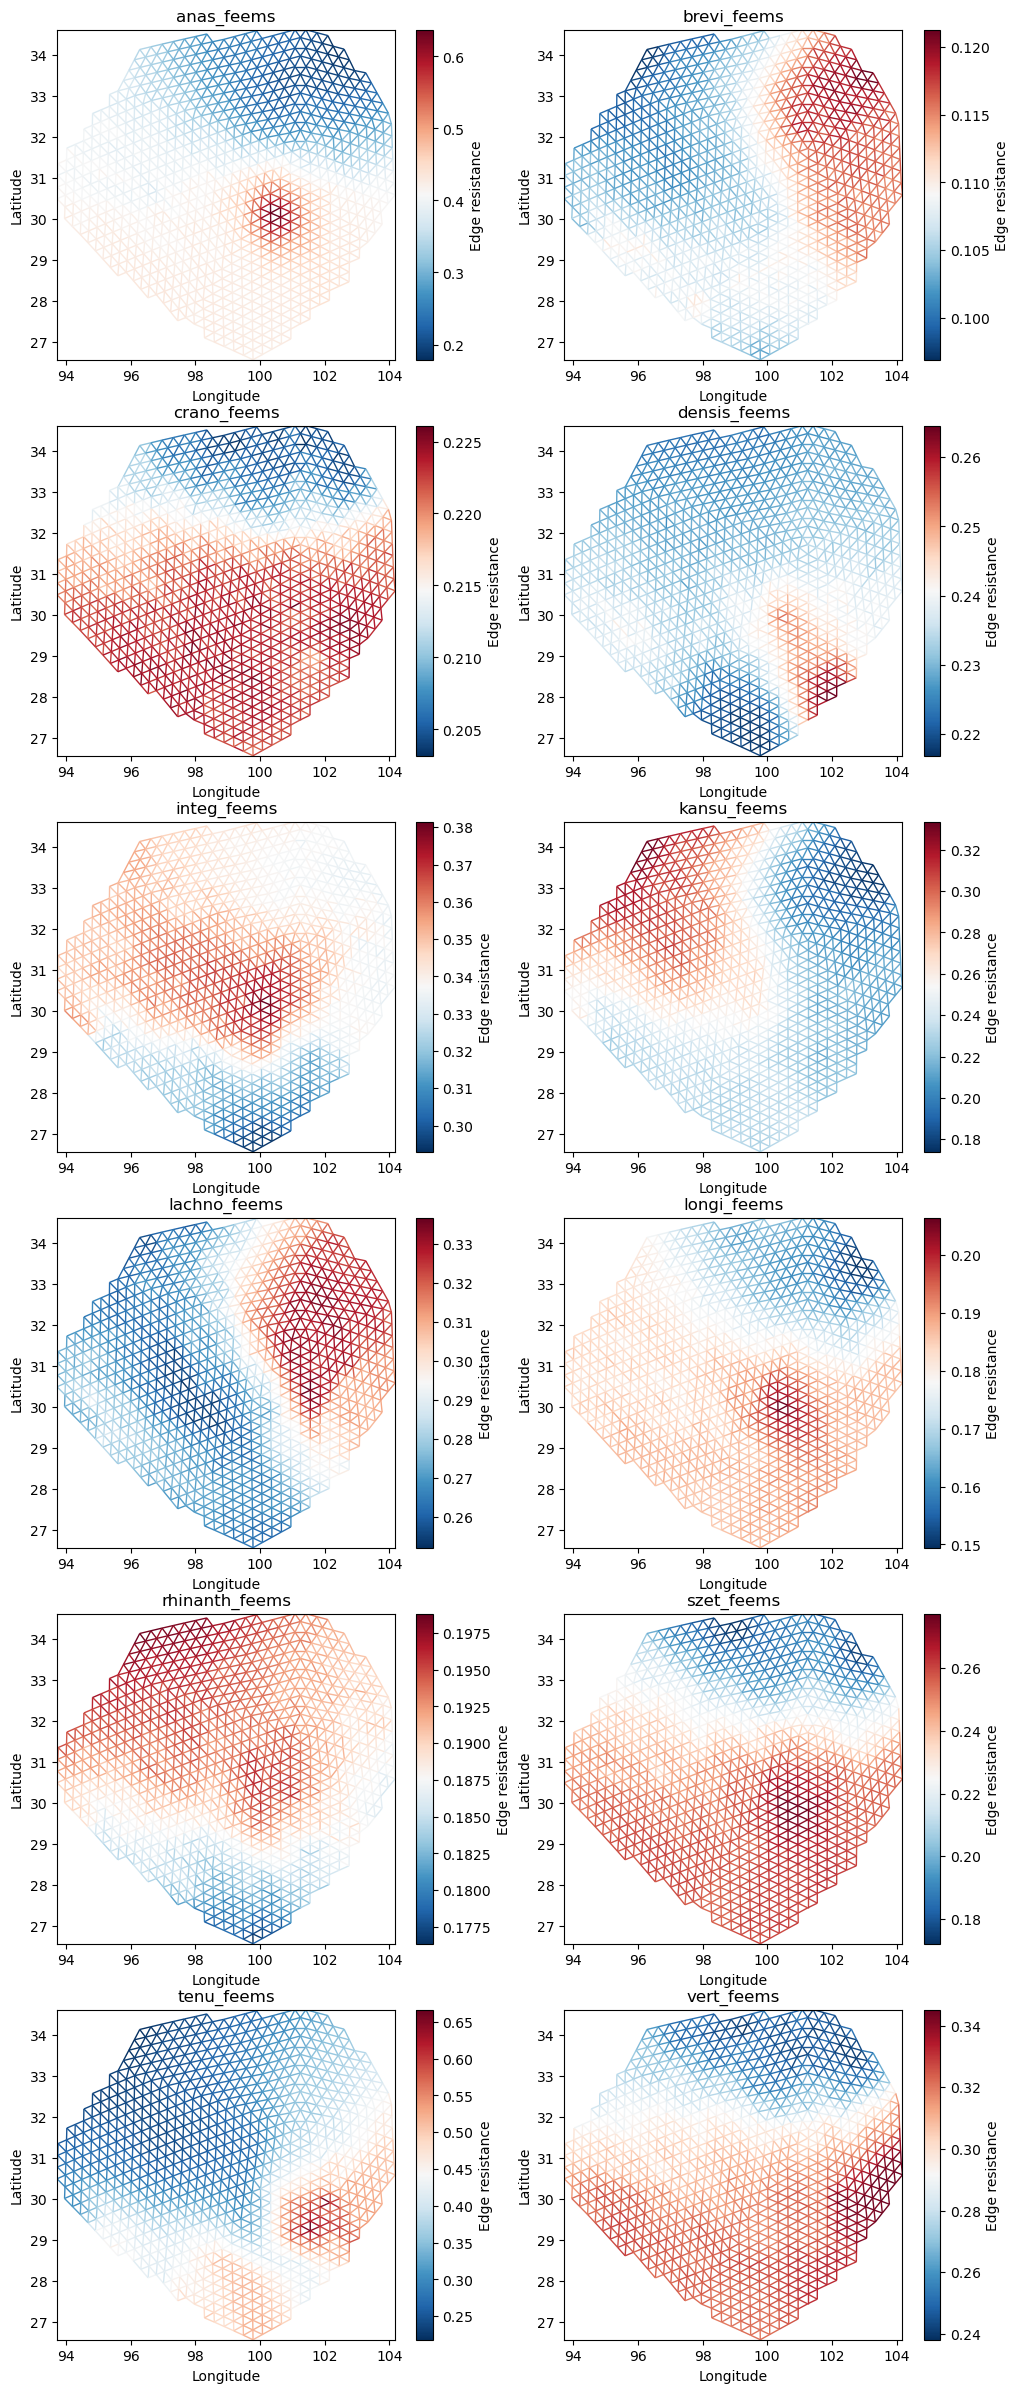

In [78]:
# Multi-species edge resistances (subplot grid)
_ = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    basemap=False,#"USGS.USTopo",
    show_sites=True,
    explore=True,
    overlay=False,
    outdir="Figs",
)


<Axes: xlabel='X', ylabel='Y'>

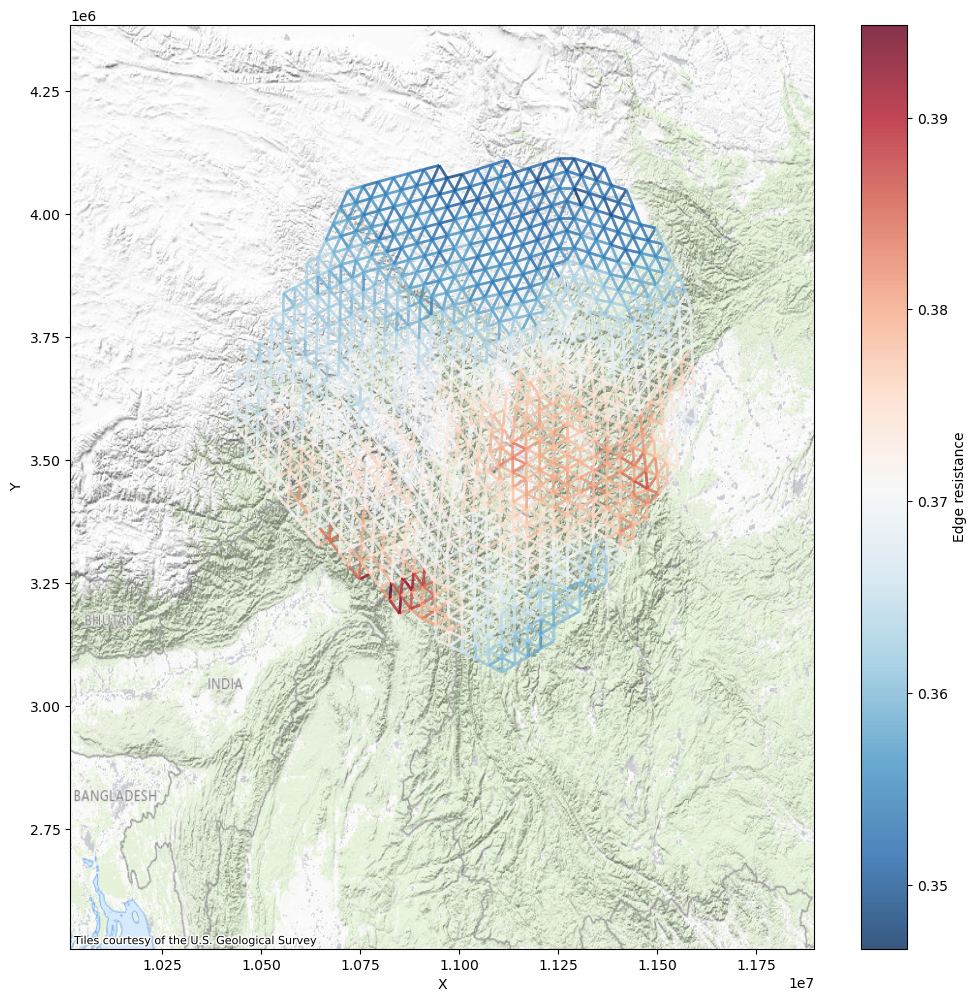

In [33]:
# Shared resistance surface (rasterized)
fig = plot_shared_resistance(
    species_list,
    graphs,
    model,
    alpha=0.8,
    show_sites=False,
    basemap="USGS.USTopo",
    figsize=(12,12),
    outfile="Shared.png",
)
fig[0]

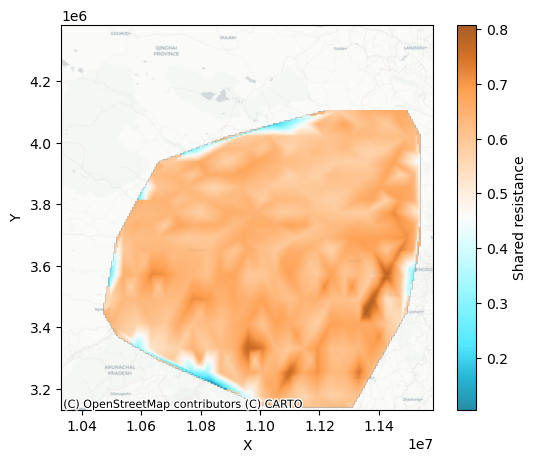

In [17]:
# Shared resistance surface (rasterized)
fig = plot_shared_resistance(
    species_list,
    graphs,
    model,
    #graph_index=1,
    rasterize=True,
    #interpolation='kriging',
    grid_size=200,
    #explore=True,
    #show_sites=True,
)


In [18]:
from multispecies_resistance.cv import choose_edge_smoothing_cv

res = choose_edge_smoothing_cv(graphs)

choose_edge_smoothing_cv: best edge_smoothing=0.5000 (mean_validation_loss=0.033636)                                    
edge_smoothing CV summary:
  edge_smoothing=0.0000 mean_validation_loss=0.086135 std=0.047563
  edge_smoothing=0.0500 mean_validation_loss=0.067918 std=0.036652
  edge_smoothing=0.1000 mean_validation_loss=0.084190 std=0.061403
  edge_smoothing=0.2000 mean_validation_loss=0.074425 std=0.034715
  edge_smoothing=0.3500 mean_validation_loss=0.062143 std=0.052218
  edge_smoothing=0.5000 mean_validation_loss=0.033636 std=0.031045
  edge_smoothing=0.7000 mean_validation_loss=0.045366 std=0.041283
  edge_smoothing=0.8500 mean_validation_loss=0.074130 std=0.027250
  edge_smoothing=0.9300 mean_validation_loss=0.062945 std=0.036154
  edge_smoothing=0.9700 mean_validation_loss=0.063963 std=0.035973


In [36]:
# Extract shared resistance edges
edge_feat = torch.from_numpy(graphs[0].edge_features)
shared = (torch.nn.functional.softplus(model.shared(edge_feat).squeeze(-1)) + 1e-4).detach().numpy()

np.save("popgen_shared_edge_resistance.npy", shared)

In [ ]:
ones = np.ones(diff.shape)
ones[0] = 0

_ = plot_species_resistance(
    g.node_coords,
    g.edge_index,
    edge_values=ones,
    basemap="USGS.USTopo",
    #basemap=None,
    alpha=0.8,
    cmap="binary",
    show_sites=False,
    sample_coords=species_list[0].sample_coords,
    figsize=(12,10),
    outfile="grid.png",
)

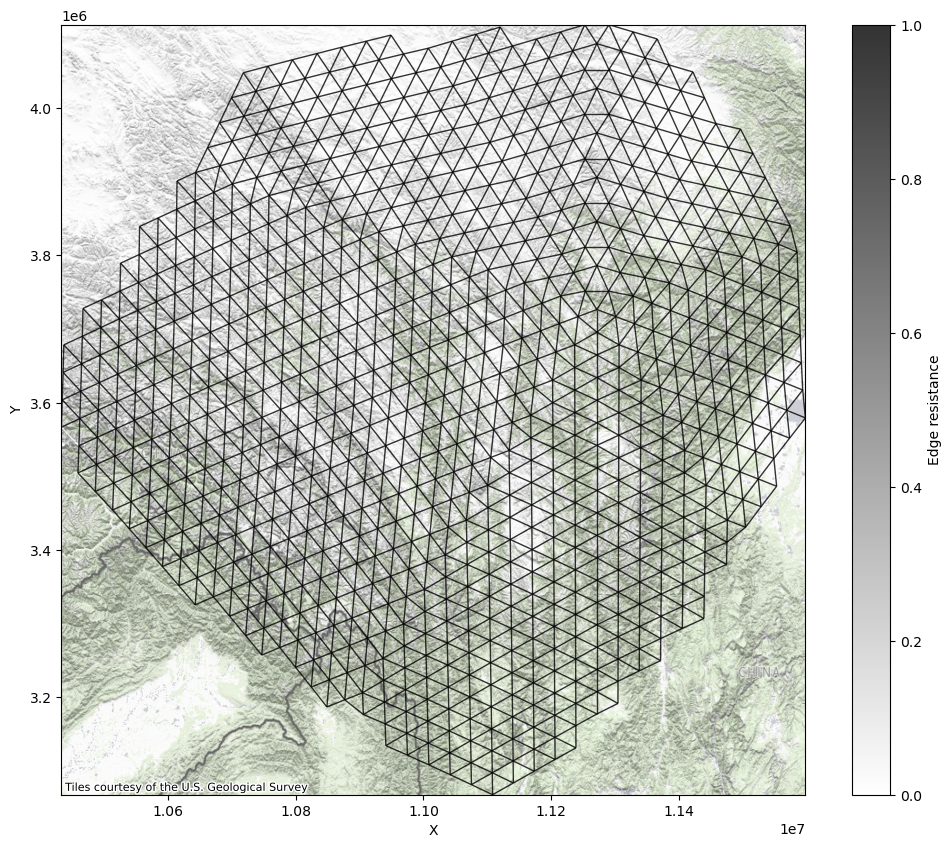

In [52]:
from multispecies_resistance.viz import plot_species_resistance

idx = 7

ones = np.ones(graphs[idx].edge_index.shape)[:, 0]
ones[0] = 0

_ = plot_species_resistance(
    graphs[idx].node_coords,
    graphs[idx].edge_index,
    edge_values=ones,
    basemap="USGS.USTopo",
    #basemap=None,
    alpha=0.8,
    cmap="binary",
    show_sites=True,
    sample_coords=species_list[idx].sample_coords,
    figsize=(12,10),
    outfile="grid.png",
)

In [66]:
species_list[0]

SpeciesData(name='anas_feems', genotypes=memmap([[0, 0, 0, ..., 1, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(32, 12388)), sample_coords=array([[ 31.4039   ,  99.9661   ],
       [ 30.0580556, 101.341667 ],
       [ 30.7406389, 101.334361 ],
       [ 31.5965556, 100.368972 ],
       [ 31.6273611, 100.234361 ],
       [ 31.5866111, 100.141667 ],
       [ 31.7153056,  99.6162778],
       [ 32.0612778,  99.0094444],
       [ 32.0668611,  99.0042222],
       [ 30.9808333,  98.9590556],
       [ 30.2970278,  99.671    ],
       [ 30.22325  , 100.264278 ],
       [ 31.7615278, 100.757222 ],
       [ 31.7247222, 100.742667 ],
       [ 32.1712222, 101.088694 ],
       [ 32.3252778, 101.080639 ],
       [ 32.3224167, 102.455417 ],
       [ 32.5355556, 102.3325   ],
       [ 32.7111111, 102.117361 ],
       [ 32.9080556, 101.890556 ],
       [ 33.3